# DM Density Profiles — AIDA-TNG (L35n1080 / 50A)

Using the pre-computed profile catalogs from `postprocessing/cat_halo_profiles_*.hdf5`.

Structure per FoF group:
- `r`: 40 log10-spaced bin edges (log10(r/kpc))
- `prof_dm`, `prof_gas`, `prof_stars`: density in 39 bins (Msun/kpc^3)

Available at z=0 (snap 99): CDM, WDM3, vSIDM. SIDM1 hydro stops at snap 83 (z≈0.2).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import h5py
from pathlib import Path
from galaxy_sidm.data.aida_tng import load_precomputed_profiles
from galaxy_sidm.observables import measure_inner_slope, compute_gamma_dm

AIDA_BASE = Path("/leonardo_work/CNHPC_1478837/AIDA/L35n1080")
NB_DIR = Path("/leonardo/home/userexternal/acosta01/master_thesis_project/notebooks/AIDA-TNG")
FIG_DIR = NB_DIR / "figures"

RUNS = {
    "CDM": AIDA_BASE / "L35n1080_CDM",
    "SIDM1": AIDA_BASE / "L35n1080_SIDM1",
    "WDM3": AIDA_BASE / "L35n1080_WDM3",
    "vSIDM": AIDA_BASE / "L35n1080_vSIDM_correa",
}

# Cosmology
h = 0.6774

# Softening (50/A): eps = 0.57 kpc physical
eps_dm = 0.57  # kpcdo 
r_fit_min = 3 * eps_dm  # ~1.7 kpc

print(f"DM softening: {eps_dm} kpc")
print(f"Min reliable radius (3*eps): {r_fit_min:.2f} kpc")

DM softening: 0.57 kpc
Min reliable radius (3*eps): 1.71 kpc


In [2]:
# Load group catalogs for all runs at their latest available snapshot
snap_map = {"CDM": 99, "SIDM1": 83, "WDM3": 99, "vSIDM": 99}

catalogs = {}
for name, run_path in RUNS.items():
    snap = snap_map[name]
    basePath = str(run_path / "output")
    fields = ["Group_M_Crit200", "Group_R_Crit200", "GroupLenType"]
    cat = il.groupcat.loadHalos(basePath, snap, fields=fields)
    cat["M200c"] = cat["Group_M_Crit200"] * 1e10 / h  # Msun
    cat["R200c"] = cat["Group_R_Crit200"] / h  # kpc
    cat["N_dm"] = cat["GroupLenType"][:, 1]
    cat["snap"] = snap
    catalogs[name] = cat
    print(f"{name} (snap {snap}): {cat['count']} halos, "
          f"{(cat['N_dm'] >= 1000).sum()} with N_DM >= 1000")

CDM (snap 99): 1326589 halos, 30583 with N_DM >= 1000
SIDM1 (snap 83): 1366631 halos, 31679 with N_DM >= 1000
WDM3 (snap 99): 1010298 halos, 28129 with N_DM >= 1000
vSIDM (snap 99): 1338573 halos, 30593 with N_DM >= 1000


In [3]:
# Load profiles — use_test=True for FP (hydro)
profiles_cdm = load_precomputed_profiles(RUNS["CDM"], 99, use_test=True)
print(f"Loaded {len(profiles_cdm)} CDM profiles")

Loaded 68828 CDM profiles


## Individual DM density profiles at z=0

Plot a few halos across mass bins for CDM, WDM3, and vSIDM (all at snap 99, z=0).

In [4]:
# Select a few halos across mass bins from CDM catalog
cat_cdm = catalogs["CDM"]
m200 = cat_cdm["M200c"]
n_dm = cat_cdm["N_dm"]

# Mass bins: pick one representative halo per bin (most massive with N_DM >= 1000)
mass_bins = [
    (8e10, 2e11, r"$8\times10^{10} - 2\times10^{11}$"),
    (8e11, 2e12, r"$8\times10^{11} - 2\times10^{12}$"),
    (8e12, 2e13, r"$8\times10^{13} - 2\times10^{13}$"),
]

example_halos = []
for m_lo, m_hi, label in mass_bins:
    sel = (m200 >= m_lo) & (m200 < m_hi) & (n_dm >= 1000)
    if sel.sum() == 0:
        print(f"No halos in {label}")
        continue
    # Pick the most massive one
    idx = np.where(sel)[0]
    best = idx[np.argmax(m200[idx])]
    example_halos.append((best, label))
    print(f"{label} Msun: halo {best}, M200c = {m200[best]:.2e} Msun, "
          f"R200c = {cat_cdm['R200c'][best]:.1f} kpc, N_DM = {n_dm[best]}")

print(f"\nSelected {len(example_halos)} example halos")

$8\times10^{10} - 2\times10^{11}$ Msun: halo 894, M200c = 2.00e+11 Msun, R200c = 123.2 kpc, N_DM = 54604
$8\times10^{11} - 2\times10^{12}$ Msun: halo 105, M200c = 1.99e+12 Msun, R200c = 265.3 kpc, N_DM = 657770
$8\times10^{13} - 2\times10^{13}$ Msun: halo 15, M200c = 1.79e+13 Msun, R200c = 551.9 kpc, N_DM = 5502552

Selected 3 example halos


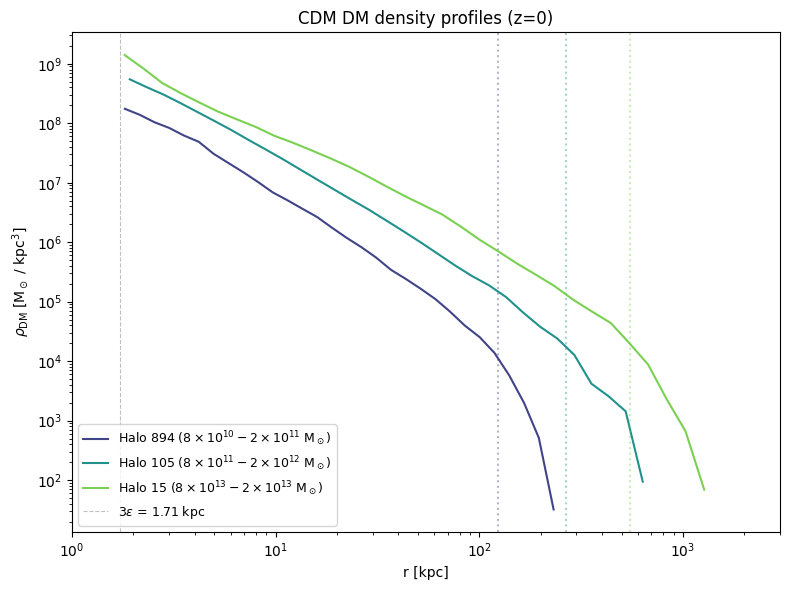

In [5]:
# Plot DM density profiles for example CDM halos
fig, ax = plt.subplots(figsize=(8, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(example_halos)))

for (hid, label), color in zip(example_halos, colors):
    if hid not in profiles_cdm:
        print(f"Halo {hid} not in profile catalog, skipping")
        continue
    
    prof = profiles_cdm[hid]
    r = prof["r_mid"]
    rho = prof["prof_dm"]
    
    # Mask: only plot where density > 0 and r >= softening limit
    valid = (rho > 0) & (r >= r_fit_min)
    
    ax.plot(r[valid], rho[valid], color=color, lw=1.5,
            label=f"Halo {hid} ({label} M$_\\odot$)")
    
    # Mark R200c
    r200 = cat_cdm["R200c"][hid]
    ax.axvline(r200, color=color, ls=":", alpha=0.4) # this is just a visual guide for R200c

ax.axvline(r_fit_min, color="gray", ls="--", lw=0.8, alpha=0.5, label=f"$3\\epsilon$ = {r_fit_min:.2f} kpc")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("r [kpc]")
ax.set_ylabel(r"$\rho_{\rm DM}$ [M$_\odot$ / kpc$^3$]")
ax.set_title("CDM DM density profiles (z=0)")
ax.legend(fontsize=9)
ax.set_xlim(1, 3000)
plt.tight_layout()
plt.savefig(FIG_DIR / "cdm_dm_profiles_examples.pdf", dpi=150)
plt.show()

## Multi-model comparison: CDM vs WDM3 vs vSIDM at z=0

For the same mass bin, compare density profiles across DM models.

In [6]:
# Load profiles for WDM3 and vSIDM at z=0 (use_test for FP runs)
profiles_wdm3 = load_precomputed_profiles(RUNS["WDM3"], 99, use_test=True)
profiles_vsidm = load_precomputed_profiles(RUNS["vSIDM"], 99, use_test=True)
print(f"WDM3: {len(profiles_wdm3)} profiles")
print(f"vSIDM: {len(profiles_vsidm)} profiles")

WDM3: 58182 profiles
vSIDM: 69319 profiles


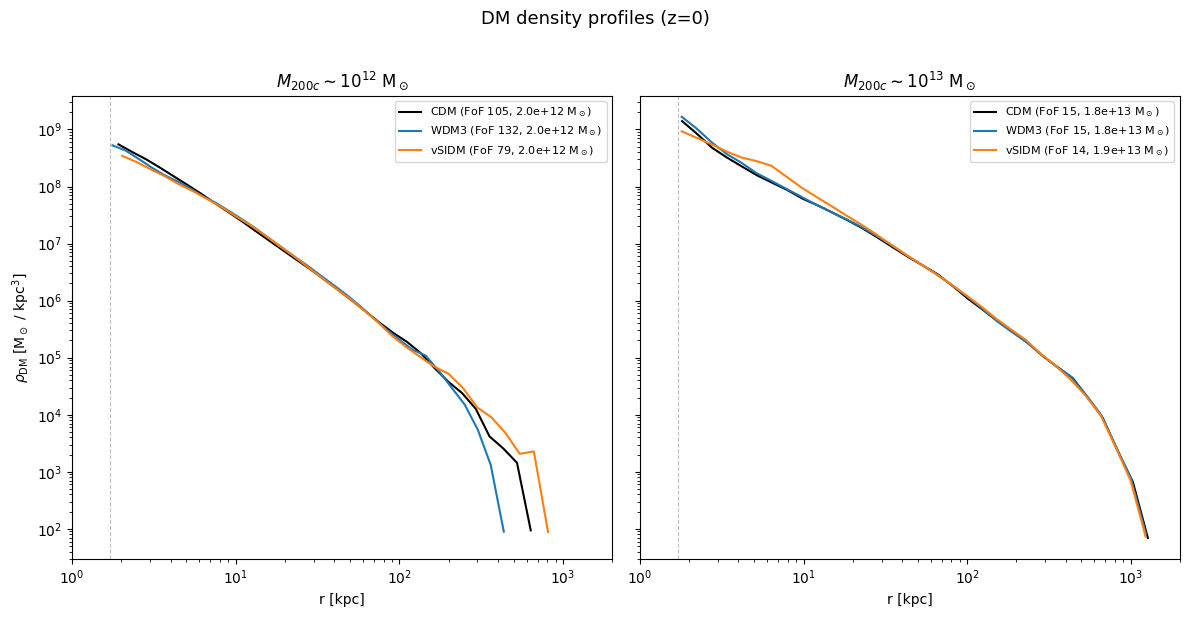

In [7]:
# Compare profiles across models for a ~10^12 Msun halo
# Use the matched subhalo catalogs to find the same object across runs

model_profiles = {"CDM": profiles_cdm, "WDM3": profiles_wdm3, "vSIDM": profiles_vsidm}
model_colors = {"CDM": "black", "WDM3": "tab:blue", "vSIDM": "tab:orange"}

# Mass bins for comparison panels
comp_bins = [
    (8e11, 2e12, r"$M_{200c} \sim 10^{12}$ M$_\odot$"),
    (8e12, 2e13, r"$M_{200c} \sim 10^{13}$ M$_\odot$"),
]

fig, axes = plt.subplots(1, len(comp_bins), figsize=(6 * len(comp_bins), 6), sharey=True)
if len(comp_bins) == 1:
    axes = [axes]

for ax, (m_lo, m_hi, bin_label) in zip(axes, comp_bins):
    for model_name in ["CDM", "WDM3", "vSIDM"]:
        cat = catalogs[model_name]
        profs = model_profiles[model_name]
        
        sel = (cat["M200c"] >= m_lo) & (cat["M200c"] < m_hi) & (cat["N_dm"] >= 1000)
        if sel.sum() == 0:
            print(f"No halos for {model_name} in {bin_label}")
            continue
        
        idx = np.where(sel)[0]
        # Pick the most massive
        best = idx[np.argmax(cat["M200c"][idx])]
        
        if best not in profs:
            print(f"Halo {best} not in {model_name} profile catalog")
            continue
        
        prof = profs[best]
        r = prof["r_mid"]
        rho = prof["prof_dm"]
        valid = (rho > 0) & (r >= r_fit_min)
        
        ax.plot(r[valid], rho[valid], color=model_colors[model_name], lw=1.5,
                label=f"{model_name} (FoF {best}, {cat['M200c'][best]:.1e} M$_\\odot$)")
    
    ax.axvline(r_fit_min, color="gray", ls="--", lw=0.8, alpha=0.5)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("r [kpc]")
    ax.set_title(bin_label)
    ax.legend(fontsize=8)
    ax.set_xlim(1, 2000)

axes[0].set_ylabel(r"$\rho_{\rm DM}$ [M$_\odot$ / kpc$^3$]")
fig.suptitle("DM density profiles (z=0)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "dm_profiles_model_comparison.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Inner DM slope $\gamma_{\rm DM}$ vs $M_{200c}$

Measure $\gamma_{\rm DM} = d\log\rho / d\log r$ in the inner region for all halos with $N_{\rm DM} \geq 1000$, using pre-computed profiles.

In [8]:
# Run for z=0 models
gamma_results = compute_gamma_dm(
    catalogs, model_profiles={"CDM": profiles_cdm, "WDM3": profiles_wdm3, "vSIDM": profiles_vsidm},
    models=["CDM", "WDM3", "vSIDM"],
    r_fit_min=r_fit_min,
)

CDM: 30572/30572 halos with valid gamma_DM
WDM3: 28097/28097 halos with valid gamma_DM
vSIDM: 30586/30586 halos with valid gamma_DM


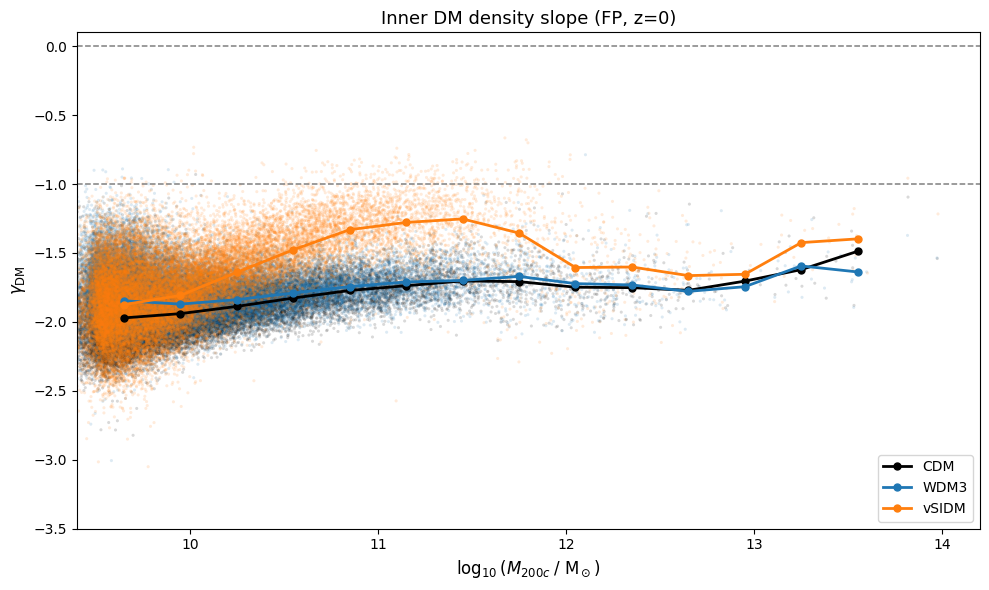

In [9]:
# gamma_DM vs M200c
fig, ax = plt.subplots(figsize=(10, 6))

model_colors = {"CDM": "black", "WDM3": "tab:blue", "vSIDM": "tab:orange"}

for name in ["CDM", "WDM3", "vSIDM"]:
    res = gamma_results[name]
    log_m = np.log10(res["M200c"])
    gamma = res["gamma_dm"]
    
    # Scatter
    ax.scatter(log_m, gamma, s=5, alpha=0.15, color=model_colors[name], edgecolors="none")
    
    # Running median
    bins = np.arange(9.5, 14.5, 0.3)
    medians, bin_centres = [], []
    for j in range(len(bins) - 1):
        in_bin = (log_m >= bins[j]) & (log_m < bins[j + 1])
        if in_bin.sum() >= 5:
            medians.append(np.median(gamma[in_bin]))
            bin_centres.append(0.5 * (bins[j] + bins[j + 1]))
    
    ax.plot(bin_centres, medians, "o-", color=model_colors[name], lw=2, ms=5, label=name)

ax.axhline(-1, color="gray", ls="--", lw=1.1)
ax.axhline(0, color="gray", ls="--", lw=1.1)
ax.set_xlabel(r"$\log_{10}(M_{200c}\;/\;\mathrm{M_\odot})$", fontsize=12)
ax.set_ylabel(r"$\gamma_{\rm DM}$", fontsize=12)
ax.set_title(r"Inner DM density slope (FP, z=0)", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(9.4, 14.2)
ax.set_ylim(-3.5, 0.1)
plt.tight_layout()
plt.savefig(FIG_DIR / "gamma_dm_vs_m200c_aida.pdf", dpi=150)
plt.show()

## DMO comparison

Same $\gamma_{\rm DM}$ measurement for the dark-matter-only runs. CDM-DMO should cluster around $\gamma = -1$ (NFW), while SIDM models should show shallower slopes (cores). doesn't...

In [10]:
RUNS_DMO = {
    "CDM-Dark": AIDA_BASE / "L35n1080_CDM-Dark",
    "WDM3-Dark": AIDA_BASE / "L35n1080_WDM3-Dark",
    "vSIDM-Dark": AIDA_BASE / "L35n1080_vSIDM_correa-Dark",
}

catalogs_dmo = {}
for name, run_path in RUNS_DMO.items():
    basePath = str(run_path / "output")
    fields = ["Group_M_Crit200", "Group_R_Crit200", "GroupLenType"]
    cat = il.groupcat.loadHalos(basePath, 99, fields=fields)
    cat["M200c"] = cat["Group_M_Crit200"] * 1e10 / h
    cat["R200c"] = cat["Group_R_Crit200"] / h
    cat["N_dm"] = cat["GroupLenType"][:, 1]
    catalogs_dmo[name] = cat
    print(f"{name}: {cat['count']} halos, {(cat['N_dm'] >= 1000).sum()} with N_DM >= 1000")

profiles_dmo = {}
for name, run_path in RUNS_DMO.items():
    profiles_dmo[name] = load_precomputed_profiles(run_path, 99)
    print(f"{name}: {len(profiles_dmo[name])} profiles")

CDM-Dark: 846050 halos, 32876 with N_DM >= 1000
WDM3-Dark: 548078 halos, 30399 with N_DM >= 1000
vSIDM-Dark: 838593 halos, 32610 with N_DM >= 1000
CDM-Dark: 267050 profiles
WDM3-Dark: 175170 profiles
vSIDM-Dark: 264671 profiles


In [11]:
gamma_results_dmo = compute_gamma_dm(
    catalogs_dmo, profiles_dmo,
    models=["CDM-Dark", "WDM3-Dark", "vSIDM-Dark"],
    r_fit_min=r_fit_min,
)

CDM-Dark: 32871/32871 halos with valid gamma_DM
WDM3-Dark: 30382/30382 halos with valid gamma_DM
vSIDM-Dark: 32606/32606 halos with valid gamma_DM


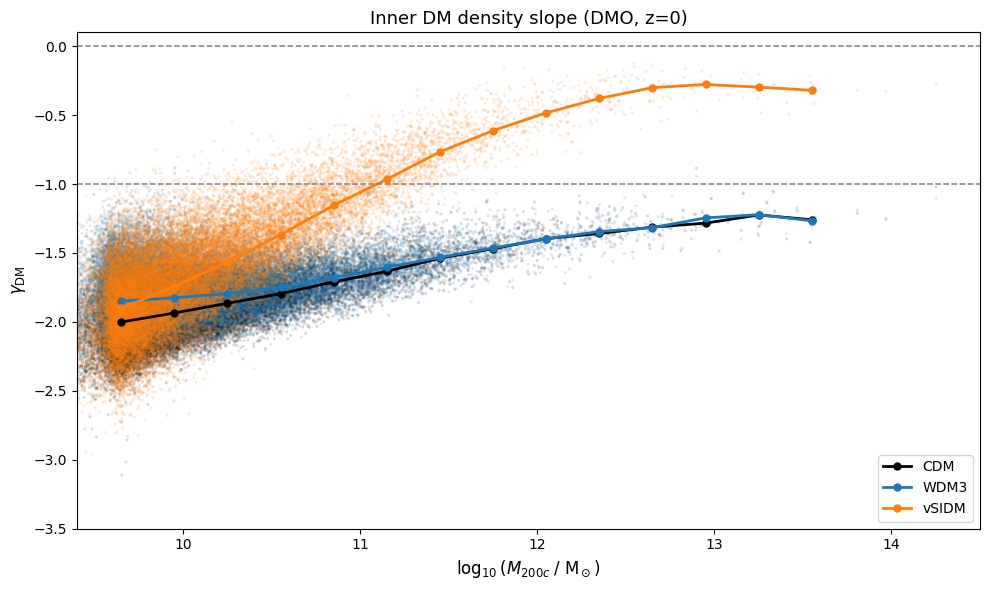

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

model_colors_dmo = {"CDM-Dark": "black", "WDM3-Dark": "tab:blue", "vSIDM-Dark": "tab:orange"}

for name in ["CDM-Dark", "WDM3-Dark", "vSIDM-Dark"]:
    res = gamma_results_dmo[name]
    log_m = np.log10(res["M200c"])
    gamma = res["gamma_dm"]

    ax.scatter(log_m, gamma, s=5, alpha=0.15, color=model_colors_dmo[name], edgecolors="none")

    bins = np.arange(9.5, 14.5, 0.3)
    medians, bin_centres = [], []
    for j in range(len(bins) - 1):
        in_bin = (log_m >= bins[j]) & (log_m < bins[j + 1])
        if in_bin.sum() >= 5:
            medians.append(np.median(gamma[in_bin]))
            bin_centres.append(0.5 * (bins[j] + bins[j + 1]))

    ax.plot(bin_centres, medians, "o-", color=model_colors_dmo[name], lw=2, ms=5,
            label=name.replace("-Dark", ""))

ax.axhline(-1, color="gray", ls="--", lw=1.1)
ax.axhline(0, color="gray", ls="--", lw=1.1)
ax.set_xlabel(r"$\log_{10}(M_{200c}\;/\;\mathrm{M_\odot})$", fontsize=12)
ax.set_ylabel(r"$\gamma_{\rm DM}$", fontsize=12)
ax.set_title(r"Inner DM density slope (DMO, z=0)", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(9.4, 14.5)
ax.set_ylim(-3.5, 0.1)
plt.tight_layout()
plt.savefig(FIG_DIR / "gamma_dm_vs_m200c_dmo.pdf", dpi=150)
plt.show()

## Slope fit diagnostic

/tmp/ipykernel_3204580/1120014135.py:13: RuntimeWarning: divide by zero encountered in log10
  sel = (np.abs(np.log10(cat["M200c"]) - logm_target) < 0.3) & (cat["N_dm"] >= 1000)


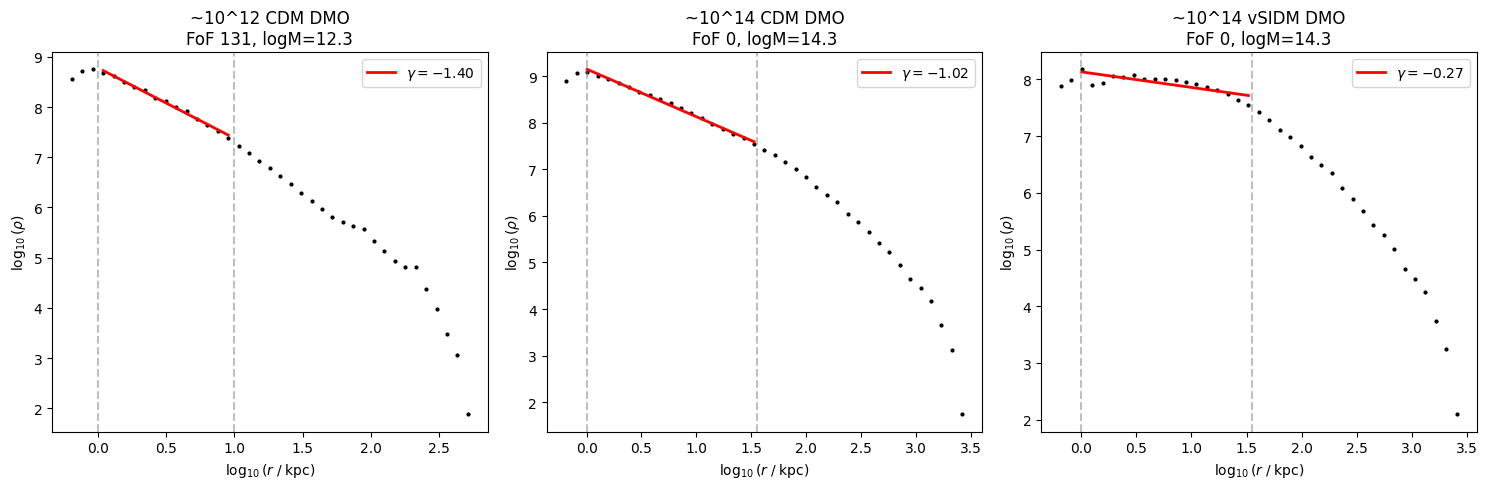

In [ ]:
test_cases = [
    ("CDM-Dark", catalogs_dmo, profiles_dmo, "~10^12 CDM DMO", 12.0),
    ("CDM-Dark", catalogs_dmo, profiles_dmo, "~10^14 CDM DMO", 14.0),
    ("vSIDM-Dark", catalogs_dmo, profiles_dmo, "~10^14 vSIDM DMO", 14.0),
]

fig, axes = plt.subplots(1, len(test_cases), figsize=(5 * len(test_cases), 5))

for ax, (model, cats, profs, title, logm_target) in zip(axes, test_cases):
    cat = cats[model]
    prof_dict = profs[model]
    
    sel = (np.abs(np.log10(cat["M200c"]) - logm_target) < 0.3) & (cat["N_dm"] >= 1000) # select halos around target mass with enough DM particles
    idx = np.where(sel)[0]
    hid = idx[np.argmax(cat["M200c"][idx])]
    
    p = prof_dict[hid]
    r, rho = p["r_mid"], p["prof_dm"]
    r200 = cat["R200c"][hid]
    
    r_inner = 1.0
    r_outer = max(0.03 * r200, 10.0)
    mask = (r >= r_inner) & (r <= r_outer) & (rho > 0)
    
    gamma = measure_inner_slope(r, rho, r_inner, r_outer)
    
    # Plot profile
    valid = (rho > 0) & (r >= 0.5)
    ax.plot(np.log10(r[valid]), np.log10(rho[valid]), "k.", ms=4)
    
    # Plot fit line
    log_r_fit = np.log10(r[mask])
    fit = np.polyfit(log_r_fit, np.log10(rho[mask]), 1)
    r_line = np.linspace(log_r_fit.min(), log_r_fit.max(), 50)
    ax.plot(r_line, np.polyval(fit, r_line), "r-", lw=2,
            label=rf"$\gamma = {gamma:.2f}$")
    
    # Mark fitting range
    ax.axvline(np.log10(r_inner), color="gray", ls="--", alpha=0.5)
    ax.axvline(np.log10(r_outer), color="gray", ls="--", alpha=0.5)
    
    ax.set_xlabel(r"$\log_{10}(r\;/\;\mathrm{kpc})$")
    ax.set_ylabel(r"$\log_{10}(\rho)$")
    ax.set_title(f"{title}\nFoF {hid}, logM={np.log10(cat['M200c'][hid]):.1f}")
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "slope_fit_diagnostic.pdf", dpi=150)
plt.show()

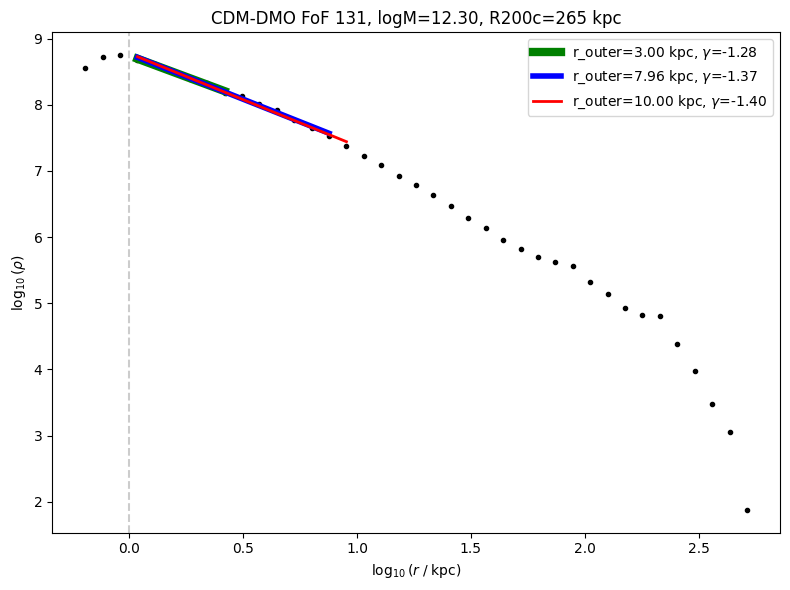

In [20]:
hid = 131
p = profiles_dmo["CDM-Dark"][hid]
r, rho = p["r_mid"], p["prof_dm"]
r200 = catalogs_dmo["CDM-Dark"]["R200c"][hid]
m200_val = catalogs_dmo["CDM-Dark"]["M200c"][hid]

fig, ax = plt.subplots(figsize=(8, 6))

valid = (rho > 0) & (r >= 0.5)
ax.plot(np.log10(r[valid]), np.log10(rho[valid]), "k.", ms=6)

for r_out, color, wid in [(3.0, "green", 6), (0.03 * r200, "blue", 4), (max(0.03 * r200, 10.0), "red", 2)]:
    mask = (r >= 1.0) & (r <= r_out) & (rho > 0)
    if mask.sum() < 2:
        continue
    gamma = measure_inner_slope(r, rho, 1.0, r_out)
    log_r_fit = np.log10(r[mask])
    fit = np.polyfit(log_r_fit, np.log10(rho[mask]), 1)
    r_line = np.linspace(log_r_fit.min(), log_r_fit.max(), 50)
    ax.plot(r_line, np.polyval(fit, r_line), color=color, lw=wid,
            label=rf"r_outer={r_out:.2f} kpc, $\gamma$={gamma:.2f}")

ax.axvline(0, color="gray", ls="--", alpha=0.4)
ax.set_xlabel(r"$\log_{10}(r\;/\;\mathrm{kpc})$")
ax.set_ylabel(r"$\log_{10}(\rho)$")
ax.set_title(f"CDM-DMO FoF {hid}, logM={np.log10(m200_val):.2f}, R200c={r200:.0f} kpc")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "slope_fit_fof131.pdf", dpi=150)
plt.show()